# Stage 2 Scoring Engine (Ticket Sale Prediction & Scoring)
### RnA Team, April 2026

## Setup

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import json
import warnings
warnings.filterwarnings('ignore')

## Load Data & Train Stage 1 Model

The Stage 1 model predicts ticket demand (avg_tickets_sold) using artist, market, and time features. For the scoring engine, we include ticket_price_avg and avg_event_capacity as inputs so the model can respond to different price/venue scenarios.

In [76]:
df = pd.read_csv("/Users/ethanc/RnA/data/test_sample_cleaned_apr8.csv")
with open("/Users/ethanc/RnA/data/scaler_stats_apr8.json") as f:
    scaler_stats = json.load(f)

def to_real(scaled_val, col):
    """Inverse z-score: scaled → original units"""
    return scaled_val * scaler_stats[col]["std"] + scaler_stats[col]["mean"]

def to_scaled(real_val, col):
    """Z-score: original units → scaled"""
    return (real_val - scaler_stats[col]["mean"]) / scaler_stats[col]["std"]

In [77]:
model = XGBRegressor()
model.load_model("/Users/ethanc/RnA/data/stage1_ticket_sales_model.json")

## Peer Grouping and 3x3 Grid Functions

In [78]:
def simplify_genre(genre_str):
    """Map raw genre strings to major categories."""
    if pd.isna(genre_str):
        return 'Other'
    if 'Latin' in genre_str:
        return 'Latin'
    if 'Pop / Rock' in genre_str:
        return 'Pop / Rock'
    if 'Country' in genre_str:
        return 'Country'
    if 'Rap' in genre_str or 'HipHop' in genre_str:
        return 'Rap / HipHop'
    if 'Dance' in genre_str or 'Electronic' in genre_str:
        return 'Dance / Electronic'
    if 'Asian Pop' in genre_str:
        return 'Asian Pop'
    return 'Other'

df['genre_group'] = df['genre'].apply(simplify_genre)
df['demand_tier'] = pd.qcut(df['avg_tickets_sold'], q=3, labels=['Low', 'Mid', 'High'])

def find_peers(event_idx, data, min_peers=10):
    genre = data.loc[event_idx, 'genre_group']
    tier = data.loc[event_idx, 'demand_tier']

    peers = data[(data['genre_group'] == genre) & (data['demand_tier'] == tier)]
    match_type = 'genre + tier'

    if len(peers) < min_peers:
        peers = data[data['genre_group'] == genre]
        match_type = 'genre only (fallback)'

    # Exclude the event itself from its peer group
    peers = peers.drop(index=event_idx, errors='ignore')
    peer_info = {
        'genre': genre,
        'tier': tier,
        'match_type': match_type,
        'num_peers': len(peers)
    }

    return peers, peer_info

def build_grid(peers, percentiles=[0.25, 0.50, 0.75]):
    price_levels = peers['ticket_price_avg'].quantile(percentiles).values
    capacity_levels = peers['avg_event_capacity'].quantile(percentiles).values

    grid_info = {
        'price_labels': ['Low', 'Mid', 'High'],
        'capacity_labels': ['Small', 'Mid', 'Large'],
        'price_values': price_levels,
        'capacity_values': capacity_levels,
        'percentiles_used': percentiles
    }

    return price_levels, capacity_levels, grid_info

## Run Stage 1 to Predict Ticket Sales

Choose event, predict ticket sales using the model, compare to actual ticket sales.

In [79]:
test_idx = 58

In [80]:
target_event_df = df.loc[test_idx]
model_features = model.get_booster().feature_names

# Build a single-row DataFrame with the event's features
X_event = pd.DataFrame([target_event_df[model_features]])

# Predict (output is z-scored avg_tickets_sold)
pred_scaled = model.predict(X_event)[0]
pred_tickets = to_real(pred_scaled, "avg_tickets_sold")

actual_tickets  = to_real(target_event_df["avg_tickets_sold"],  "avg_tickets_sold")
actual_price    = to_real(target_event_df["ticket_price_avg"],  "ticket_price_avg")
actual_capacity = to_real(target_event_df["avg_event_capacity"],"avg_event_capacity")

print(f"Artist:           {target_event_df['headliner']}")
print(f"Venue:            {target_event_df['venue']}  ({actual_capacity:,.0f} seats)")
print(f"Avg ticket price: ${actual_price:,.0f}")
print(f"Actual tickets:   {actual_tickets:,.0f}")
print(f"Predicted tickets:{pred_tickets:,.0f}")

Artist:           Portugal. The Man
Venue:            Steelhouse Omaha  (2,633 seats)
Avg ticket price: $35
Actual tickets:   1,146
Predicted tickets:4,836


## Predict ticket sales for each option in the 3x3 grid

In [81]:
# Find peers and build grid for event
peers, peer_info = find_peers(test_idx, df)
price_s, cap_s, grid_info = build_grid(peers)

print(f"Peer group: {peer_info['num_peers']} events ({peer_info['match_type']})")

price_labels = [f"${to_real(p, 'ticket_price_avg'):.0f}" for p in price_s]
cap_labels = [f"{to_real(c, 'avg_event_capacity'):.0f}" for c in cap_s]
print(f"Price levels:  {price_labels}")
print(f"Capacity levels: {cap_labels}")

Peer group: 318 events (genre + tier)
Price levels:  ['$28', '$40', '$55']
Capacity levels: ['913', '1163', '1513']


In [82]:
# For each of the 9 combinations, copy the event's features and swap in the grid price/capacity
rows = []
for cap in cap_s:
    for price in price_s:
        row = target_event_df[model_features].copy()
        row["ticket_price_avg"]   = price
        row["avg_event_capacity"] = cap
        rows.append(row)

X_grid = pd.DataFrame(rows, columns=model_features)

# Predict all 9 and transform to real ticket counts
preds_scaled  = model.predict(X_grid)
preds_tickets = np.array([to_real(p, "avg_tickets_sold") for p in preds_scaled])
preds_tickets = np.clip(preds_tickets, 0, None).reshape(3, 3)  # rows=capacity, cols=price

# Display as a table
real_prices = [to_real(p, "ticket_price_avg")    for p in price_s]
real_caps   = [to_real(c, "avg_event_capacity")  for c in cap_s]
row_labels = [f"{l} venue ({c:,.0f} seats)" for l, c in zip(grid_info["capacity_labels"], real_caps)]
col_labels = [f"{l} price (${p:,.0f})"      for l, p in zip(grid_info["price_labels"],    real_prices)]
pd.DataFrame(preds_tickets.round(0).astype(int), index=row_labels, columns=col_labels)

,Low price ($28),Mid price ($40),High price ($55)
Small venue (913 seats),4122,4127,4227
"Mid venue (1,163 seats)",4292,4296,4396
"Large venue (1,513 seats)",4416,4420,4520


## Scoring Engine - Table

- Cap predicted ticketsat venue capacity
- Compute revenue = ticket price × predicted tickets sold
- Flag the combination with the highest revenue as the recommendation


In [83]:
# 1. Cap predicted tickets at venue capacity
tickets_sold = np.array([
    [min(preds_tickets[i, j], real_caps[i]) for j in range(3)]
    for i in range(3)
])

# 2. Compute revenue for each combination
fill_rates = (tickets_sold / np.array(real_caps).reshape(3, 1)) * 100
revenues   = np.array([
    [real_prices[j] * tickets_sold[i, j] for j in range(3)]
    for i in range(3)
])

# 3. Find the combination with the highest revenue
best_i, best_j = np.unravel_index(np.argmax(revenues), revenues.shape)

print(f"{'':30s} {'Low ($'+str(int(real_prices[0]))+')':>18} {'Mid ($'+str(int(real_prices[1]))+')':>18} {'High ($'+str(int(real_prices[2]))+')':>18}")
print("-" * 84)
for i, cap_label in enumerate(grid_info["capacity_labels"]):
    row_str = f"{cap_label} venue ({real_caps[i]:,.0f} seats):"
    for j in range(3):
        marker = " ★" if (i, j) == (best_i, best_j) else ""
        row_str += f"   ${revenues[i,j]:>8,.0f} ({fill_rates[i,j]:.0f}% fill){marker}"
    print(row_str)

print(f"\n★  Recommended: {grid_info['price_labels'][best_j]} price (${real_prices[best_j]:,.0f}) × {grid_info['capacity_labels'][best_i]} venue ({real_caps[best_i]:,.0f} seats)")
print(f"   Tickets sold: {tickets_sold[best_i, best_j]:,.0f}  |  Fill rate: {fill_rates[best_i, best_j]:.0f}%")
print(f"   Expected revenue: ${revenues[best_i, best_j]:,.0f}")

                                        Low ($28)          Mid ($39)         High ($54)
------------------------------------------------------------------------------------
Small venue (913 seats):   $  26,014 (100% fill)   $  36,279 (100% fill)   $  49,774 (100% fill)
Mid venue (1,163 seats):   $  33,128 (100% fill)   $  46,200 (100% fill)   $  63,386 (100% fill)
Large venue (1,513 seats):   $  43,091 (100% fill)   $  60,094 (100% fill)   $  82,449 (100% fill) ★

★  Recommended: High price ($55) × Large venue (1,513 seats)
   Tickets sold: 1,513  |  Fill rate: 100%
   Expected revenue: $82,449


## Scoring Engine - Figure

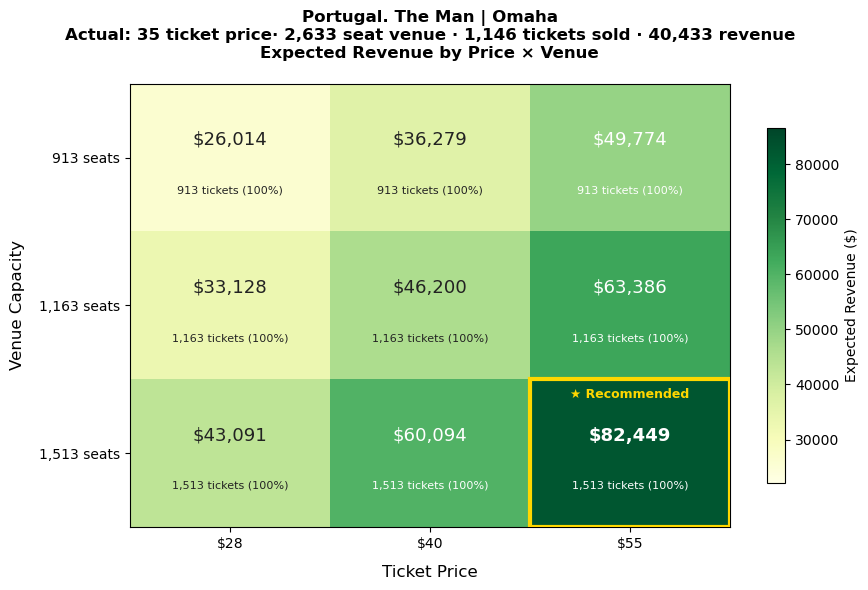

In [84]:
best_idx = (best_i, best_j)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(revenues, cmap="YlGn", aspect="auto",
               vmin=revenues.min() * 0.85, vmax=revenues.max() * 1.05)

for i in range(3):
    for j in range(3):
        is_best   = (i, j) == best_idx
        txt_color = "white" if revenues[i, j] > revenues.mean() else "#222"
        ax.text(j, i - 0.12, f"${revenues[i, j]:,.0f}",
                ha="center", va="center", fontsize=13,
                fontweight="bold" if is_best else "normal",
                color=txt_color)
        ax.text(j, i + 0.22, f"{tickets_sold[i,j]:,.0f} tickets ({fill_rates[i,j]:.0f}%)",
                ha="center", va="center", fontsize=8, color=txt_color)

# Highlight winning cell
ax.add_patch(patches.Rectangle(
    (best_idx[1] - 0.5, best_idx[0] - 0.5), 1, 1,
    linewidth=3, edgecolor="gold", facecolor="none", zorder=5))
ax.text(best_idx[1], best_idx[0] - 0.4, "★ Recommended",
        ha="center", va="center", fontsize=9,
        color="gold", fontweight="bold", zorder=6)

x_labels = [f"${p:,.0f}" for p in real_prices]
y_labels = [f"{c:,.0f} seats" for c in real_caps]

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel("Ticket Price", fontsize=12, labelpad=10)
ax.set_ylabel("Venue Capacity", fontsize=12, labelpad=10)

actual_price = to_real(target_event_df["ticket_price_avg"], "ticket_price_avg")
actual_cap   = to_real(target_event_df["avg_event_capacity"], "avg_event_capacity")
actual_tickets = to_real(target_event_df["avg_tickets_sold"], "avg_tickets_sold")
actual_revenue = to_real(target_event_df["avg_gross_usd"], "avg_gross_usd")

ax.set_title(
    f"{target_event_df['headliner']} | {target_event_df['market']}\n"
    f"Actual: {actual_price:,.0f} ticket price· {actual_cap:,.0f} seat venue · {actual_tickets:,.0f} tickets sold · {actual_revenue:,.0f} revenue\n"
    f"Expected Revenue by Price × Venue\n",
    fontsize=12, fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.8, label="Expected Revenue ($)")
plt.tight_layout()
plt.savefig("scoring_engine_figure.png",dpi=300)

In [85]:
# ═══ Scoring Engine Validation ═══
# For each event, run the full scoring engine and compare
# recommended revenue vs actual revenue

model_features = model.get_booster().feature_names
validation_results = []

for idx in df.index:
    genre = df.loc[idx, 'genre_group']
    tier = df.loc[idx, 'demand_tier']

    # Find peers
    peers = df[(df['genre_group'] == genre) & (df['demand_tier'] == tier)].drop(index=idx, errors='ignore')
    if len(peers) < 10:
        peers = df[df['genre_group'] == genre].drop(index=idx, errors='ignore')
    if len(peers) < 5:
        continue

    # Build grid
    prices = peers['ticket_price_avg'].quantile([0.25, 0.50, 0.75]).values
    caps = peers['avg_event_capacity'].quantile([0.25, 0.50, 0.75]).values

    # Score all 9 combos, find best revenue
    best_rev = -np.inf
    for cap in caps:
        for price in prices:
            e = pd.DataFrame([df.loc[idx][model_features]])
            e['ticket_price_avg'] = price
            e['avg_event_capacity'] = cap
            pred = model.predict(e)[0]
            pred = min(pred, cap) if cap > 0 else pred
            rev = price * pred
            if rev > best_rev:
                best_rev = rev

    # Actual revenue
    actual_rev = df.loc[idx, 'ticket_price_avg'] * df.loc[idx, 'avg_tickets_sold']

    validation_results.append({
        'genre': genre, 'tier': tier,
        'actual_revenue': actual_rev,
        'recommended_revenue': best_rev,
        'improved': best_rev >= actual_rev
    })

val = pd.DataFrame(validation_results)

# Summary
print(f"Events scored: {len(val)}")
print(f"Recommendation matches or beats actual: {val['improved'].sum()}/{len(val)} ({val['improved'].mean()*100:.0f}%)")
print(f"\nBy genre:")
for genre in val['genre'].unique():
    sub = val[val['genre'] == genre]
    print(f"  {genre:20s}: {sub['improved'].mean()*100:.0f}% improved (n={len(sub)})")

Events scored: 1808
Recommendation matches or beats actual: 572/1808 (32%)

By genre:
  Asian Pop           : 0% improved (n=31)
  Pop / Rock          : 34% improved (n=857)
  Latin               : 70% improved (n=250)
  Country             : 0% improved (n=225)
  Other               : 35% improved (n=253)
  Rap / HipHop        : 7% improved (n=102)
  Dance / Electronic  : 7% improved (n=90)


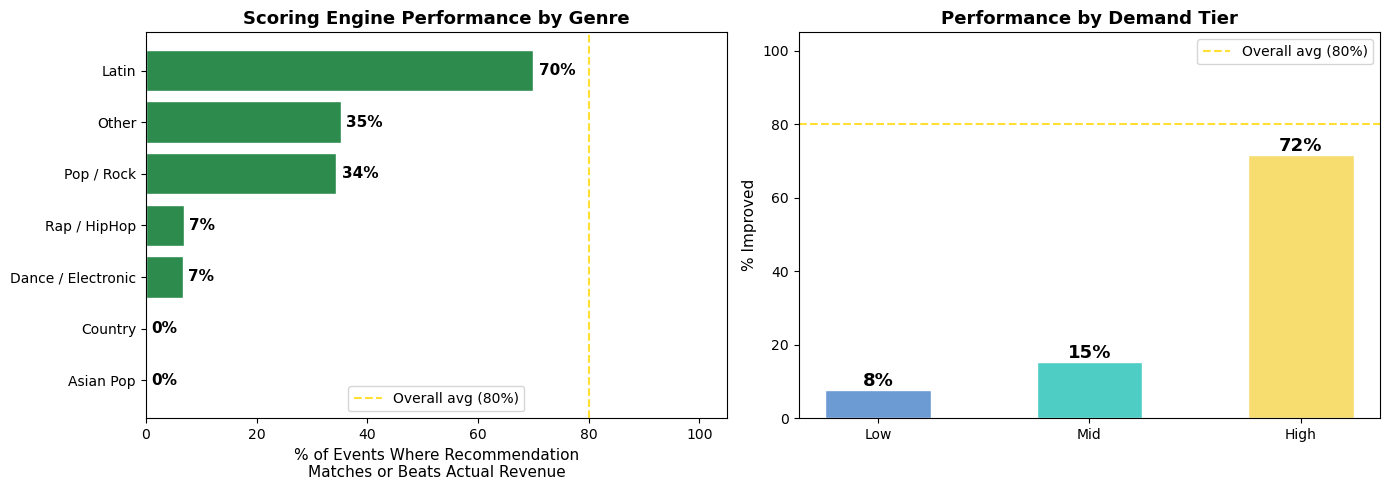

In [86]:
# validation visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: % improved by genre
ax1 = axes[0]
genre_stats = val.groupby('genre')['improved'].mean().sort_values() * 100
bars = ax1.barh(genre_stats.index, genre_stats.values, color='#2D8B4E', edgecolor='white')
ax1.axvline(80, color='gold', linestyle='--', alpha=0.8, label='Overall avg (80%)')
ax1.set_xlabel('% of Events Where Recommendation\nMatches or Beats Actual Revenue', fontsize=11)
ax1.set_title('Scoring Engine Performance by Genre', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(0, 105)
for bar, v in zip(bars, genre_stats.values):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{v:.0f}%', va='center', fontsize=11, fontweight='bold')

# Plot 2: % improved by demand tier
ax2 = axes[1]
tier_stats = val.groupby('tier')['improved'].mean().reindex(['Low','Mid','High']) * 100
tier_colors = ['#6B9BD2', '#4ECDC4', '#F7DC6F']
bars2 = ax2.bar(tier_stats.index, tier_stats.values, color=tier_colors, edgecolor='white', width=0.5)
ax2.axhline(80, color='gold', linestyle='--', alpha=0.8, label='Overall avg (80%)')
ax2.set_ylabel('% Improved', fontsize=11)
ax2.set_title('Performance by Demand Tier', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=10)
for bar, v in zip(bars2, tier_stats.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{v:.0f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
#plt.savefig("scoring_engine_validation.png", dpi=200, bbox_inches='tight')
plt.show()

In [87]:
model_features = model.get_booster().feature_names
bias_results = []

for idx in df.index:
    genre = df.loc[idx, 'genre_group']
    tier = df.loc[idx, 'demand_tier']
    peers = df[(df['genre_group'] == genre) & (df['demand_tier'] == tier)].drop(index=idx, errors='ignore')
    if len(peers) < 10:
        peers = df[df['genre_group'] == genre].drop(index=idx, errors='ignore')
    if len(peers) < 5:
        continue

    prices = peers['ticket_price_avg'].quantile([0.25, 0.50, 0.75]).values
    caps = peers['avg_event_capacity'].quantile([0.25, 0.50, 0.75]).values

    best_rev = -np.inf
    best_pi = None
    for ci, cap in enumerate(caps):
        for pi, price in enumerate(prices):
            e = pd.DataFrame([df.loc[idx][model_features]])
            e['ticket_price_avg'] = price
            e['avg_event_capacity'] = cap
            pred = max(model.predict(e)[0], 0)
            pred = min(pred, cap) if cap > 0 else pred
            rev = price * pred
            if rev > best_rev:
                best_rev = rev
                best_pi = pi
    bias_results.append({'best_price_tier': best_pi})

bias_df = pd.DataFrame(bias_results)
tier_labels = ['Low', 'Mid', 'High']
print("Price tier recommendations (current scoring engine):")
for i, label in enumerate(tier_labels):
    pct = (bias_df['best_price_tier'] == i).mean() * 100
    print(f"  {label} price:  {pct:.0f}%")

Price tier recommendations (current scoring engine):
  Low price:  6%
  Mid price:  0%
  High price:  94%


In [88]:
def score_event_with_elasticity(idx, df, model, model_features, elasticity=-0.5):
    """
    Score one event with price elasticity adjustment.

    The model is run at the median peer price (the most reliable point),
    then demand is adjusted up or down based on the candidate price.
    """
    genre = df.loc[idx, 'genre_group']
    tier = df.loc[idx, 'demand_tier']
    peers = df[(df['genre_group'] == genre) & (df['demand_tier'] == tier)].drop(index=idx, errors='ignore')
    if len(peers) < 10:
        peers = df[df['genre_group'] == genre].drop(index=idx, errors='ignore')
    if len(peers) < 5:
        return None

    prices_z = peers['ticket_price_avg'].quantile([0.25, 0.50, 0.75]).values
    caps_z = peers['avg_event_capacity'].quantile([0.25, 0.50, 0.75]).values
    median_price_z = prices_z[1]

    # Convert z-score price to dollar
    prices_real = [to_real(p, 'ticket_price_avg') for p in prices_z]
    median_price_real = prices_real[1]

    best_rev = -np.inf
    best_pi, best_ci = None, None

    for ci, cap_z in enumerate(caps_z):
        cap_real = to_real(cap_z, 'avg_event_capacity')
        for pi, price_z in enumerate(prices_z):
            # Predict at MEDIAN price (avoids extrapolation into biased regions)
            e = pd.DataFrame([df.loc[idx][model_features]])
            e['ticket_price_avg'] = median_price_z
            e['avg_event_capacity'] = cap_z
            pred_z = max(model.predict(e)[0], 0)
            pred_tickets = to_real(pred_z, 'avg_tickets_sold')
            pred_tickets = max(pred_tickets, 0)

            # Apply elasticity: adjust demand based on % price change from median
            price_pct_change = (prices_real[pi] - median_price_real) / median_price_real
            demand_multiplier = 1 + (elasticity * price_pct_change)
            demand_multiplier = max(demand_multiplier, 0.1)  # floor to prevent negatives

            pred_adjusted = pred_tickets * demand_multiplier
            pred_adjusted = min(pred_adjusted, cap_real) if cap_real > 0 else pred_adjusted

            rev = prices_real[pi] * pred_adjusted
            if rev > best_rev:
                best_rev = rev
                best_pi = pi
                best_ci = ci

    return {'best_price_tier': best_pi, 'best_cap_tier': best_ci, 'best_rev': best_rev}

# Test on the same event as Cell 9 (Portugal. The Man) for visual comparison
result = score_event_with_elasticity(test_idx, df, model, model_features, elasticity=-0.5)
print(f"Event {test_idx} with elasticity = -0.5:")
print(f"  Recommended: {tier_labels[result['best_price_tier']]} price × {tier_labels[result['best_cap_tier']]} venue")
print(f"  Expected revenue: ${result['best_rev']:,.0f}")

Event 58 with elasticity = -0.5:
  Recommended: High price × High venue
  Expected revenue: $82,449


In [89]:
#comparison of bias across tiers

comparison = []
for elasticity in [0.0, -0.3, -0.5, -0.8, -1.0]:
    tier_counts = [0, 0, 0]
    n_scored = 0
    for idx in df.index:
        result = score_event_with_elasticity(idx, df, model, model_features, elasticity=elasticity)
        if result is None:
            continue
        tier_counts[result['best_price_tier']] += 1
        n_scored += 1

    pcts = [c / n_scored * 100 for c in tier_counts]
    comparison.append({
        'elasticity': elasticity,
        'low_pct': pcts[0],
        'mid_pct': pcts[1],
        'high_pct': pcts[2]
    })
    print(f"Elasticity = {elasticity:5.1f}  →  Low: {pcts[0]:.0f}% | Mid: {pcts[1]:.0f}% | High: {pcts[2]:.0f}%")

comp_df = pd.DataFrame(comparison)

Elasticity =   0.0  →  Low: 0% | Mid: 0% | High: 100%
Elasticity =  -0.3  →  Low: 0% | Mid: 0% | High: 100%
Elasticity =  -0.5  →  Low: 0% | Mid: 14% | High: 86%
Elasticity =  -0.8  →  Low: 0% | Mid: 20% | High: 80%
Elasticity =  -1.0  →  Low: 0% | Mid: 22% | High: 78%


## 5x5 Grid
The 3x3 grid uses only 25th/50th/75th percentiles for prices and venues, which creates large gaps between the Low and High options. The engine often picks an extreme because the middle isn't appealing enough. A 5x5 grid uses 10/30/50/70/90 percentiles, giving 25 combinations to evaluate. With more combinations, we can see whether the engine's bias toward extremes is actually real, or just because it has too few options.

In [90]:
#same functions but changed to fit 5x5 grid instead of 3x3
def simplify_genre(genre_str):
    """Map raw genre strings to major categories."""
    if pd.isna(genre_str):
        return 'Other'
    if 'Latin' in genre_str:
        return 'Latin'
    if 'Pop / Rock' in genre_str:
        return 'Pop / Rock'
    if 'Country' in genre_str:
        return 'Country'
    if 'Rap' in genre_str or 'HipHop' in genre_str:
        return 'Rap / HipHop'
    if 'Dance' in genre_str or 'Electronic' in genre_str:
        return 'Dance / Electronic'
    if 'Asian Pop' in genre_str:
        return 'Asian Pop'
    return 'Other'

df['genre_group'] = df['genre'].apply(simplify_genre)
df['demand_tier'] = pd.qcut(df['avg_tickets_sold'], q=3, labels=['Low', 'Mid', 'High'])

def find_peers(event_idx, data, min_peers=10):
    genre = data.loc[event_idx, 'genre_group']
    tier = data.loc[event_idx, 'demand_tier']

    peers = data[(data['genre_group'] == genre) & (data['demand_tier'] == tier)]
    match_type = 'genre + tier'

    if len(peers) < min_peers:
        peers = data[data['genre_group'] == genre]
        match_type = 'genre only (fallback)'

    # Exclude the event itself from its peer group
    peers = peers.drop(index=event_idx, errors='ignore')
    peer_info = {
        'genre': genre,
        'tier': tier,
        'match_type': match_type,
        'num_peers': len(peers)
    }

    return peers, peer_info

def build_grid(peers, percentiles=[0.25, 0.50, 0.75]):
    """
    Build a grid of price x venue capacity from peer percentiles.

    Default is 3x3 (25/50/75 percentiles).
    For 5x5 grid: pass percentiles=[0.10, 0.30, 0.50, 0.70, 0.90]
    """
    price_levels = peers['ticket_price_avg'].quantile(percentiles).values
    capacity_levels = peers['avg_event_capacity'].quantile(percentiles).values

    # Auto-generate labels based on number of percentiles
    n = len(percentiles)
    if n == 3:
        price_labels = ['Low', 'Mid', 'High']
        capacity_labels = ['Small', 'Mid', 'Large']
    elif n == 5:
        price_labels = ['Very Low', 'Low', 'Mid', 'High', 'Very High']
        capacity_labels = ['Very Small', 'Small', 'Mid', 'Large', 'Very Large']
    else:
        price_labels = [f'P{int(p*100)}' for p in percentiles]
        capacity_labels = [f'C{int(p*100)}' for p in percentiles]

    grid_info = {
        'price_labels': price_labels,
        'capacity_labels': capacity_labels,
        'price_values': price_levels,
        'capacity_values': capacity_levels,
        'percentiles_used': percentiles
    }

    return price_levels, capacity_levels, grid_info


In [91]:
# 5x5 Grid for one event

peers_5x5, peer_info_5x5 = find_peers(test_idx, df)
price_5x5, cap_5x5, grid_info_5x5 = build_grid(peers_5x5, percentiles=[0.10, 0.30, 0.50, 0.70, 0.90])

real_prices_5x5 = [to_real(p, 'ticket_price_avg') for p in price_5x5]
real_caps_5x5 = [to_real(c, 'avg_event_capacity') for c in cap_5x5]

print(f"Event {test_idx} | Peer group: {peer_info_5x5['num_peers']} events")
print(f"\n5x5 Grid:")
print(f" Price levels:    {[f'${p:.0f}' for p in real_prices_5x5]}")
print(f"  Capacity levels: {[f'{c:.0f}' for c in real_caps_5x5]}")

Event 58 | Peer group: 318 events

5x5 Grid:
 Price levels:    ['$25', '$30', '$40', '$51', '$71']
  Capacity levels: ['614', '943', '1163', '1450', '1862']


In [92]:
#scoring same as 3x3

rows_5x5 = []
for cap in cap_5x5:
    for price in price_5x5:
        row = target_event_df[model_features].copy()
        row['ticket_price_avg'] = price
        row['avg_event_capacity'] = cap
        rows_5x5.append(row)

X_grid_5x5 = pd.DataFrame(rows_5x5, columns=model_features)
preds_scaled_5x5 = model.predict(X_grid_5x5)
preds_tickets_5x5 = np.array([to_real(p, 'avg_tickets_sold') for p in preds_scaled_5x5])
preds_tickets_5x5 = np.clip(preds_tickets_5x5, 0, None).reshape(5, 5)

# Cap at capacity, compute revenue
tickets_sold_5x5 = np.array([
    [min(preds_tickets_5x5[i, j], real_caps_5x5[i]) for j in range(5)]
    for i in range(5)
])
revenues_5x5 = np.array([
    [real_prices_5x5[j] * tickets_sold_5x5[i, j] for j in range(5)]
    for i in range(5)
])

best_i_5x5, best_j_5x5 = np.unravel_index(np.argmax(revenues_5x5), revenues_5x5.shape)

# Display as DataFrame
row_labels = [f"{l} ({c:,.0f} seats)" for l, c in zip(grid_info_5x5['capacity_labels'], real_caps_5x5)]
col_labels = [f"{l} (${p:,.0f})" for l, p in zip(grid_info_5x5['price_labels'], real_prices_5x5)]
rev_table = pd.DataFrame(revenues_5x5.round(0).astype(int), index=row_labels, columns=col_labels)

print(f"Recommended: {grid_info_5x5['price_labels'][best_j_5x5]} price (${real_prices_5x5[best_j_5x5]:,.0f}) × {grid_info_5x5['capacity_labels'][best_i_5x5]} venue ({real_caps_5x5[best_i_5x5]:,.0f} seats)")
print(f"Expected revenue: ${revenues_5x5[best_i_5x5, best_j_5x5]:,.0f}\n")
rev_table

Recommended: Very High price ($71) × Very Large venue (1,862 seats)
Expected revenue: $132,369



,Very Low ($25),Low ($30),Mid ($40),High ($51),Very High ($71)
Very Small (614 seats),15293,18414,24391,31381,43658
Small (943 seats),23490,28285,37465,48201,67059
"Mid (1,163 seats)",28967,34880,46200,59440,82695
"Large (1,450 seats)",36105,43475,57585,74088,103074
"Very Large (1,862 seats)",46367,55831,73952,95145,132369


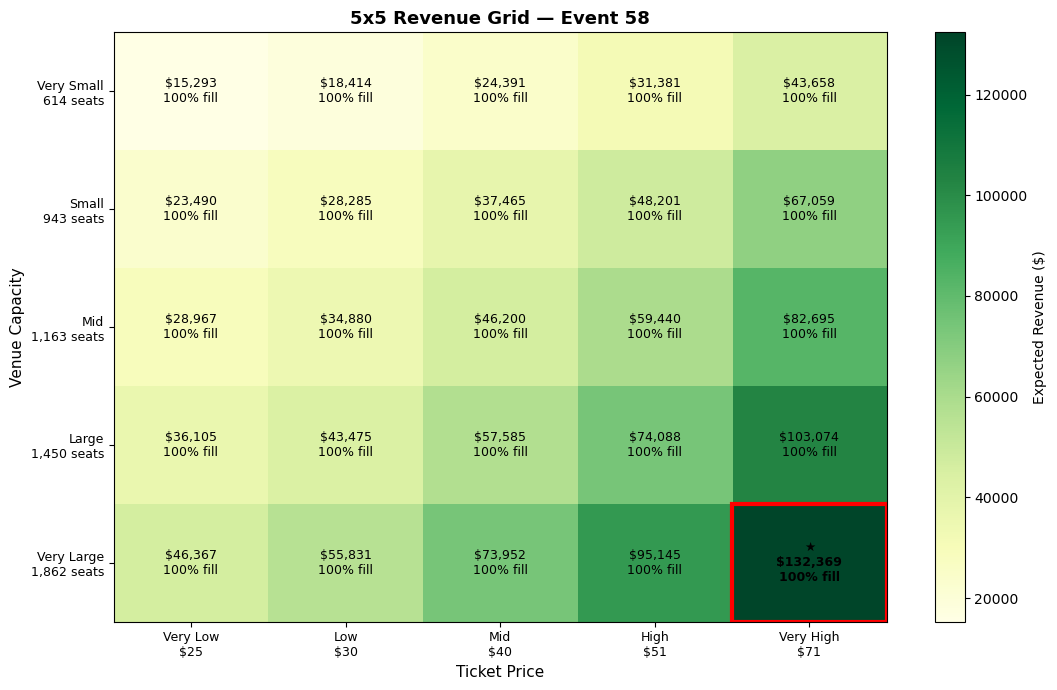

In [93]:
# Visualize the 5x5 revenue grid
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(revenues_5x5, cmap='YlGn', aspect='auto')

# Annotate each cell with revenue and fill rate
for i in range(5):
    for j in range(5):
        fill = (tickets_sold_5x5[i, j] / real_caps_5x5[i]) * 100
        text = f"${revenues_5x5[i,j]:,.0f}\n{fill:.0f}% fill"
        if (i, j) == (best_i_5x5, best_j_5x5):
            text = '★\n' + text
        ax.text(j, i, text, ha='center', va='center', fontsize=9,
                fontweight='bold' if (i,j) == (best_i_5x5, best_j_5x5) else 'normal')

# Highlight best cell
rect = patches.Rectangle((best_j_5x5 - 0.5, best_i_5x5 - 0.5), 1, 1,
                          linewidth=3, edgecolor='red', facecolor='none')
ax.add_patch(rect)

ax.set_xticks(range(5))
ax.set_xticklabels([f"{l}\n${p:,.0f}" for l, p in zip(grid_info_5x5['price_labels'], real_prices_5x5)], fontsize=9)
ax.set_yticks(range(5))
ax.set_yticklabels([f"{l}\n{c:,.0f} seats" for l, c in zip(grid_info_5x5['capacity_labels'], real_caps_5x5)], fontsize=9)
ax.set_xlabel('Ticket Price', fontsize=11)
ax.set_ylabel('Venue Capacity', fontsize=11)
ax.set_title(f'5x5 Revenue Grid — Event {test_idx}', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Expected Revenue ($)')
plt.tight_layout()
plt.show()

## Elasticity

In [94]:
# Build residual table: for every event, get predicted demand at peer-median price, then pair the residual with the price deviation

residual_rows = []

for idx in df.index:
    genre = df.loc[idx, 'genre_group']
    tier = df.loc[idx, 'demand_tier']
    peers = df[(df['genre_group'] == genre) & (df['demand_tier'] == tier)].drop(index=idx, errors='ignore')
    if len(peers) < 10:
        peers = df[df['genre_group'] == genre].drop(index=idx, errors='ignore')
    if len(peers) < 5:
        continue

    # Reference point: median peer price
    median_price_z = peers['ticket_price_avg'].median()
    median_price_real = to_real(median_price_z, 'ticket_price_avg')

    # Predict demand at the median price (holding event's other features fixed)
    e = pd.DataFrame([df.loc[idx][model_features]])
    e['ticket_price_avg'] = median_price_z
    pred_z = max(model.predict(e)[0], 0)
    pred_tickets = to_real(pred_z, 'avg_tickets_sold')

    # Actual price and demand for this event (in real units)
    actual_price_real = to_real(df.loc[idx, 'ticket_price_avg'], 'ticket_price_avg')
    actual_demand_real = to_real(df.loc[idx, 'avg_tickets_sold'], 'avg_tickets_sold')

    # Skip degenerate cases (log undefined for non-positive values)
    if pred_tickets <= 0 or actual_demand_real <= 0 or actual_price_real <= 0 or median_price_real <= 0:
        continue
    if actual_price_real == median_price_real:
        continue  # no price variation, no elasticity signal

    log_demand_ratio = np.log(actual_demand_real / pred_tickets)
    log_price_ratio = np.log(actual_price_real / median_price_real)

    residual_rows.append({
        'idx': idx,
        'genre': genre,
        'tier': tier,
        'log_demand_ratio': log_demand_ratio,
        'log_price_ratio': log_price_ratio
    })

residuals = pd.DataFrame(residual_rows)
print(f'Built residual table: {len(residuals)} events with usable price variation')
print(f"\nEvents per genre:")
print(residuals['genre'].value_counts())

Built residual table: 1788 events with usable price variation

Events per genre:
genre
Pop / Rock            857
Other                 253
Latin                 250
Country               220
Rap / HipHop           93
Dance / Electronic     84
Asian Pop              31
Name: count, dtype: int64


In [95]:
# Fit one elasticity per genre group via OLS through the origin:
# log(actual/predicted) = beta * log(price/median_price)

def fit_elasticity(group):
    x = group['log_price_ratio'].values
    y = group['log_demand_ratio'].values
    if len(x) < 10:
        return np.nan
    # OLS slope through origin: beta = sum(xy) / sum(x^2)
    denom = np.sum(x ** 2)
    if denom == 0:
        return np.nan
    return np.sum(x * y) / denom

genre_elasticities = residuals.groupby('genre').apply(fit_elasticity)
overall_elasticity = fit_elasticity(residuals)

print(f"Default elasticity currently used:  -0.5")
print(f"Overall data-calibrated elasticity:  {overall_elasticity:.3f}")
print(f"\nGenre-specific elasticities (sample size in parens):")
for genre, beta in genre_elasticities.sort_values().items():
    n = (residuals['genre'] == genre).sum()
    print(f"  {genre:<22} {beta:+.3f}   (n={n})")

Default elasticity currently used:  -0.5
Overall data-calibrated elasticity:  -0.039

Genre-specific elasticities (sample size in parens):
  Rap / HipHop           -0.809   (n=93)
  Dance / Electronic     -0.739   (n=84)
  Country                -0.647   (n=220)
  Pop / Rock             -0.248   (n=857)
  Asian Pop              +0.038   (n=31)
  Other                  +0.681   (n=253)
  Latin                  +1.183   (n=250)


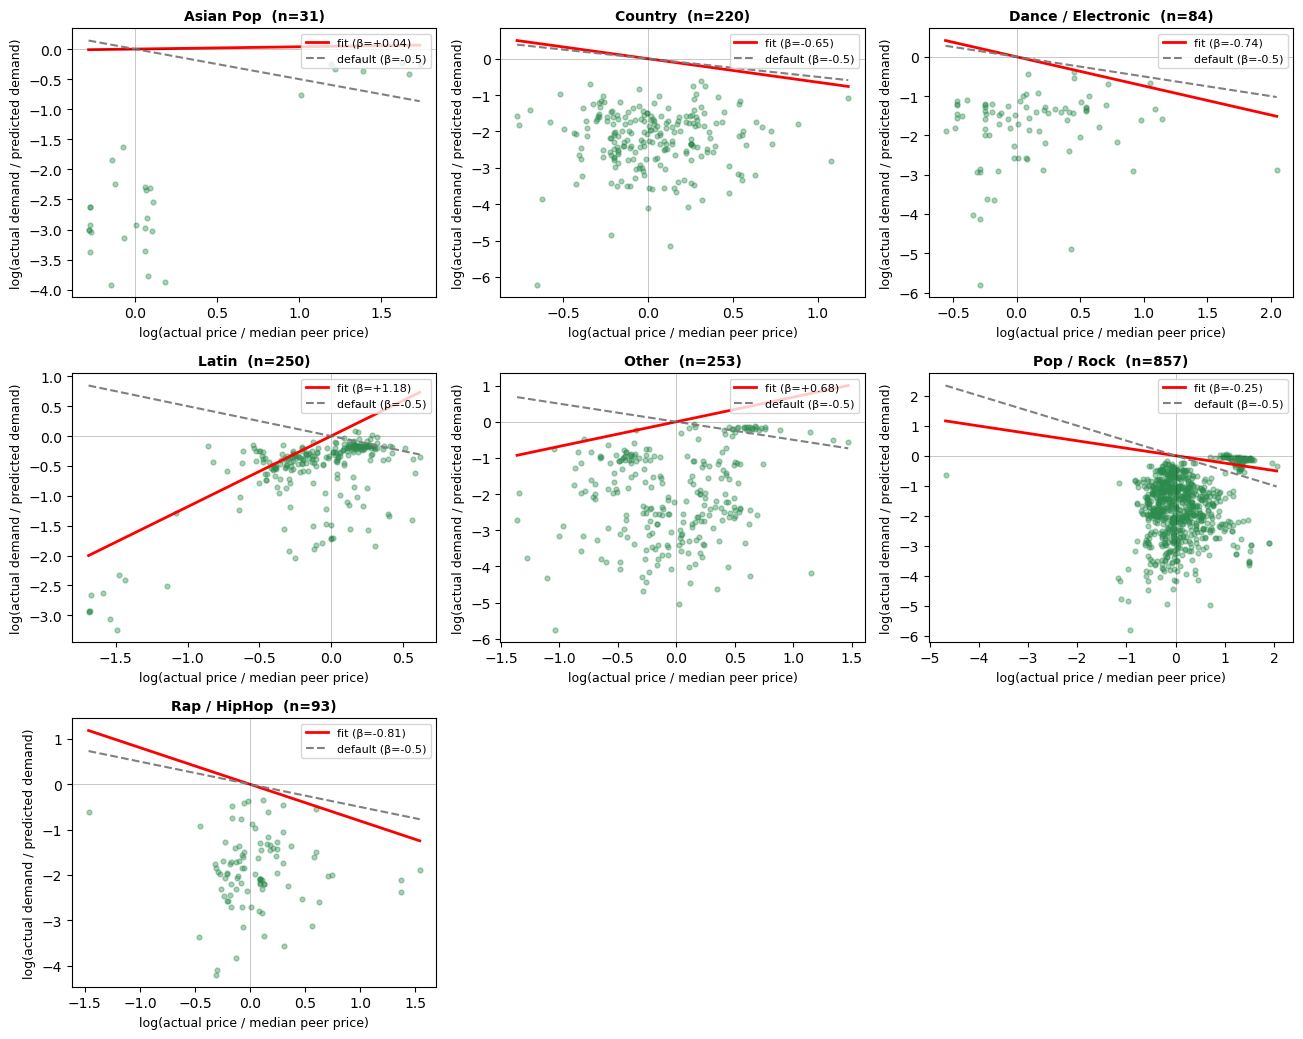

In [96]:
# Visualize residual scatter + fitted slope per genre
genres_to_plot = [g for g in genre_elasticities.index if not np.isnan(genre_elasticities[g])]
n_genres = len(genres_to_plot)
ncols = 3
nrows = int(np.ceil(n_genres / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows))
axes = axes.flatten() if n_genres > 1 else [axes]

for ax, genre in zip(axes, genres_to_plot):
    sub = residuals[residuals['genre'] == genre]
    beta = genre_elasticities[genre]
    ax.scatter(sub['log_price_ratio'], sub['log_demand_ratio'],
               s=12, alpha=0.4, color='#2D8B4E')

    x_line = np.linspace(sub['log_price_ratio'].min(), sub['log_price_ratio'].max(), 50)
    ax.plot(x_line, beta * x_line, color='red', lw=2, label=f'fit (β={beta:+.2f})')
    ax.plot(x_line, -0.5 * x_line, color='gray', lw=1.5, ls='--', label='default (β=-0.5)')
    ax.axhline(0, color='black', lw=0.5, alpha=0.3)
    ax.axvline(0, color='black', lw=0.5, alpha=0.3)

    ax.set_xlabel('log(actual price / median peer price)', fontsize=9)
    ax.set_ylabel('log(actual demand / predicted demand)', fontsize=9)
    ax.set_title(f'{genre}  (n={len(sub)})', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

for ax in axes[n_genres:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [97]:
# Score every event using the genre-calibrated elasticity, then compare against fixed -0.5

elasticity_lookup = genre_elasticities.to_dict()

def get_calibrated_elasticity(genre):
    """Pull genre-specific elasticity, with overall as fallback for missing/positive values."""
    beta = elasticity_lookup.get(genre, np.nan)
    # Guard rails: if the fit is missing or non-negative (economically nonsensical),
    # fall back to the overall calibrated value
    if np.isnan(beta) or beta >= 0:
        beta = overall_elasticity if overall_elasticity < 0 else -0.5
    return beta

calibrated_results = []
fixed_results = []

for idx in df.index:
    genre = df.loc[idx, 'genre_group']
    beta_genre = get_calibrated_elasticity(genre)

    r_cal = score_event_with_elasticity(idx, df, model, model_features, elasticity=beta_genre)
    r_fix = score_event_with_elasticity(idx, df, model, model_features, elasticity=-0.5)
    if r_cal is None or r_fix is None:
        continue

    calibrated_results.append({'genre': genre, 'best_price_tier': r_cal['best_price_tier'], 'beta': beta_genre})
    fixed_results.append({'genre': genre, 'best_price_tier': r_fix['best_price_tier']})

cal_df = pd.DataFrame(calibrated_results)
fix_df = pd.DataFrame(fixed_results)

tier_labels = ['Low', 'Mid', 'High']
print('Recommendation distribution comparison:\n')
print(f'{"Tier":<8}{"Fixed -0.5":>14}{"Calibrated":>14}')
for i, label in enumerate(tier_labels):
    p_fix = (fix_df['best_price_tier'] == i).mean() * 100
    p_cal = (cal_df['best_price_tier'] == i).mean() * 100
    print(f'{label:<8}{p_fix:>13.0f}%{p_cal:>13.0f}%')

Recommendation distribution comparison:

Tier        Fixed -0.5    Calibrated
Low                 0%            0%
Mid                14%            0%
High               86%          100%
